In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import uuid

In [40]:
# Read csv files
comment = pd.read_csv(".data/Forum comment ferpa.csv")
thread = pd.read_csv(".data/Forum thread ferpa.csv")

In [41]:
# Inspect first five rows
comment.head();

In [42]:
# Inspect first five rows
thread.head();

In [43]:
# Number of unique thread_ids compared to total comments
comment["thread_id"].nunique(), len(comment)

(3809, 9188)

In [44]:
# combine comment and thread data frame on thread_id (for comment df) and id (for thread df)
merged_df = pd.merge(comment, thread, left_on="thread_id", right_on="id", how='inner', suffixes=("_comment","_thread"))
merged_df.columns

Index(['id_comment', 'thread_id', 'parent_id', 'user_id_comment',
       'course_id_comment', 'body_comment', 'anonymous_comment',
       'anonymous_to_peers_comment', 'upvotes_comment', 'downvotes_comment',
       'abuse_flagger_count', 'historical_abuse_flagger_count', 'endorsed',
       'endorser_id', 'endorsement_time', 'updated_at_comment',
       'created_at_comment', 'id_thread', 'user_id_thread', 'commentable_id',
       'course_id_thread', 'closed', 'thread_type', 'title', 'body_thread',
       'anonymous_thread', 'anonymous_to_peers_thread', 'comment_count',
       'upvotes_thread', 'downvotes_thread', 'last_activity_at',
       'updated_at_thread', 'created_at_thread'],
      dtype='object')

In [45]:
# Inspect columns of the thread df
thread.columns;

In [46]:
# Inspect columns of the comment df
comment.columns;

In [47]:
# compare shape of df to comment
# notice that there are 1354 thread_ids in comment that are not included in thread
print("merged_df.shape",merged_df.shape)
print("comment.shape", comment.shape)
comment_wo_thread_data = comment[~comment["thread_id"].isin(merged_df["thread_id"])]
comment_wo_thread_data.shape
print("comment_wo_thread_data.shape", comment_wo_thread_data.shape)

merged_df.shape (7834, 33)
comment.shape (9188, 17)
comment_wo_thread_data.shape (1354, 17)


In [48]:
# number of ids in thread df that are not in comment df
thread_id_not_in_comment = thread[~thread["id"].isin(comment["thread_id"])]
print("thread_id_not_in_comment.shape", thread_id_not_in_comment.shape)

thread_id_not_in_comment.shape (6260, 16)


## Interpreting results
The results above show us that the thread_id from the comments dataframe and the id from the threads dataframe have some overlap but both dataframes have ids that are not shared. In the cells below we will trim the data such that all the thread_ids in the comments df and all the ids in the threads df are the same when comparing uniqueness. 

In [49]:
# Trimmed comment, thread df
comment_t = comment[comment["thread_id"].isin(merged_df["thread_id"])]
thread_t = thread[thread["id"].isin(comment["thread_id"])]

merged_df_t = pd.merge(comment_t, thread_t, left_on="thread_id", right_on="id", how='inner', suffixes=("_comment","_thread"))

print("comment_t.shape", comment_t.shape)
print("thread_t.shape", thread_t.shape)
print("merged_df_t.shape", merged_df_t.shape)

print(set(merged_df_t["thread_id"].values) == (set(comment_t["thread_id"].values) | set(thread_t["id"].values)))

comment_t.shape (7834, 17)
thread_t.shape (3024, 16)
merged_df_t.shape (7834, 33)
True


## Moving forward
We would like to have a dataframe in the following format ...
<table>
    <tr>
        <th>
            id
        </th>
        <th>
            metric
        </th>
        <th>
            text
        </th>
    <tr>
    <tr>
        <td>
            1
        </td>
        <td>
            0.5
        </td>
        <td>
            Module not Found Error: I'm getting this weird error when I run this from than command line.
        </td>
    </tr>
    <tr>
        <td>
            2
        </td>
        <td>
            -0.6
        </td>
        <td>
            Exam: How are we supposed to know this for the exam?!
        </td>
    </tr>
    <tr>
        <td>
            ...
        </td>
        <td>
            ...
        </td>
        <td>
            ...
        </td>
    </tr>
    
</table>

The choice of metric and how the metric is generated will be determined later, for now we seek to organize the data in a format that is managable for future analysis. We have a few formatting choices ...

<ol>
    <li>
    Only include the body column from the comment df and ignore the thread df body and title
    </li>
    <li>
    Combine the thread_id title and body to each comment body
    </li>
    <li>
    Combine the thread_id title to each comment body but leave the thread body separate from the comment body
    </li>
    <li>
    Ignore the thread_id relationship and look only at the title plus body for threads and body for comment df
    </li>
</ol>

Below we will create dataframes following the structure mentioned above.

In [50]:
# 1
temp = [comment, comment_t]
comment_dfs = [deepcopy(i) for i in temp]
format1 = []
for c in comment_dfs:
    c.loc[:, "metric"] = np.nan
    c = c[["id","metric","body"]]    
    c.columns = ["id", "metric", "text"]
    # I'm not sure if we need this or not, added it anyways
    c.loc[:, "id"] = [uuid.uuid4() for i in range(len(c))]
    c.set_index("id", inplace=True)
    format1.append(c)
format1[0].head()

C:\Users\djons\Anaconda3\lib\site-packages\pandas\core\indexing.py:964: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


,metric,text
id,,
782be9a3-9dbb-4bfb-a86b-b1d33bdb190d,NaN,Enter your answer without spaces! I was going ...
84b7e3e6-5943-447c-9e9a-c4f7e0159b44,NaN,SmartBook that is :)
315bcfdc-75ed-4547-b38b-57c4335ddba1,NaN,What is the answer for this question? I tried ...
c182a187-8a48-4c0d-9ca1-96f21f325535,NaN,Passed with output printed: 12 On the bubble ...
f795a71d-fcec-4a4a-96fd-5b5567cda19f,NaN,"I had the same problem with this question, I w..."


In [51]:
# 2
temp = [merged_df, merged_df_t]
delimiter = "\n\n:\n\n"
merged_dfs = [deepcopy(i) for i in temp]
format2 = []
for m in merged_dfs:
    m["metric"] = np.nan
    m["text"] = m["title"] + delimiter + m["body_thread"] + delimiter + m["body_comment"]
    # I'm not sure if we need this or not, added it anyways
    m.loc[:, "id"] = [uuid.uuid4() for i in range(len(m))]
    m = m[["id","metric","text"]]
    m.set_index("id", inplace=True)
    format2.append(m)
format2[0].head()

,metric,text
id,,
5624bf3e-506d-4486-8770-337a04d02339,NaN,3.4.3 Exercise 4\n\n:\n\nI had problem getting...
bc151546-d51f-4ffa-baff-5af3c8e8ed8b,NaN,3.4.3 Exercise 4\n\n:\n\nI had problem getting...
168215c7-cd56-4088-9bdb-587e97c01364,NaN,3.4.3 Exercise 4\n\n:\n\nI had problem getting...
209792ea-ac75-4734-abef-bc7776552e68,NaN,3.4.3 Exercise 4\n\n:\n\nI had problem getting...
f81daf1c-01d5-4c3d-abed-ff2c2eec8ae5,NaN,3.4.3 Exercise 4\n\n:\n\nI had problem getting...


In [52]:
# 3
temp = [merged_df, merged_df_t]
delimiter = "\n\n:\n\n"
merged_dfs = [deepcopy(i) for i in temp]
format3 = []
for m in merged_dfs:
    m["metric"] = np.nan
    m["text"] = m["title"] + delimiter + m["body_comment"]
    # I'm not sure if we need this or not, added it anyways
    m.loc[:, "id"] = [uuid.uuid4() for i in range(len(m))]
    m = m[["id","metric","text"]]
    m.set_index("id", inplace=True)
    format3.append(m)
format3[0].head()

,metric,text
id,,
1b75e19d-6cec-4cd1-820c-e8b1ffb26941,NaN,3.4.3 Exercise 4\n\n:\n\nEnter your answer wit...
a2925fa0-12ca-4be2-b923-b34264ffaf82,NaN,3.4.3 Exercise 4\n\n:\n\nThanks. I got it not...
dc35ca59-b328-4191-b166-fcef5fdee55e,NaN,3.4.3 Exercise 4\n\n:\n\nHow will Python know ...
e0e42d80-62d2-400f-aa84-12ac1be1e39d,NaN,3.4.3 Exercise 4\n\n:\n\nThanks for the help. ...
d780d8ad-b2a9-4d23-9e47-feae23739c4c,NaN,3.4.3 Exercise 4\n\n:\n\nThe instruction is fl...


In [53]:
# 4
temp = {"comment" : [comment, comment_t], "thread" : [thread, thread_t]}
dfs = { i : [deepcopy(j) for j in temp[i]] for i in temp }
format4 = []
for c, t in zip(*dfs.values()):
    c["metric"], t["metric"] = np.nan, np.nan
    #t["metric"] = np.nan
    c = c[["id","metric", "body"]]
    c.columns = ["id","metric","text"]
    t["text"] = t["title"] + delimiter + t["body"]
    t = t[["id","metric","text"]]
    stacked = pd.concat([c,t], axis = 0)
    stacked.loc[:, "id"] = [uuid.uuid4() for i in range(len(stacked))]
    stacked.set_index("id", inplace=True)
    format4.append(stacked)
format4[0].head()

,metric,text
id,,
17886c68-1a18-4133-9c05-4a01b7ffe10c,NaN,Enter your answer without spaces! I was going ...
15568069-eaa0-4f7c-904d-cb0bc9132769,NaN,SmartBook that is :)
afb12f4c-5b7f-4fc1-8704-ed04012017c5,NaN,What is the answer for this question? I tried ...
c4feadbf-fefb-4727-bfe0-7842954d10fa,NaN,Passed with output printed: 12 On the bubble ...
ee151489-21ed-4349-8d63-ff4afe8a4c6d,NaN,"I had the same problem with this question, I w..."


## Side notes
When considering the popularity of threads and thus the influence on the comments, it is important to consider the number of comments per thread.

20
20


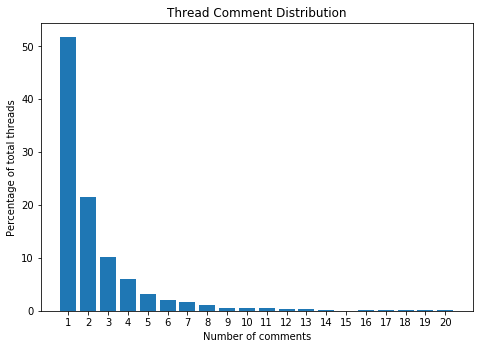

In [102]:
comments_for_each_thread_id = comment.groupby("thread_id")["thread_id"].count().sort_values(ascending=False)
# create x values
x = np.arange(1, 21)
# number of rows
length = comments_for_each_thread_id.shape[0]
# generate percentages
percentages = [(comments_for_each_thread_id == i).sum() / length * 100 for i in x[:-1]] + \
                [(comments_for_each_thread_id >= 20).sum() / length * 100] # percentage of threads with >= 20 comments
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
print(len(ubs))
print(len(percentages))
plt.bar(x = ubs, height = percentages)
plt.xticks(ubs)
ax.set_xlabel("Number of comments")
ax.set_ylabel("Percentage of total threads");
ax.set_title("Thread Comment Distribution");
plt.savefig("Thread Comment Distribution.png")

## Further exploration
Number of instructor comments for each thread

# Cognitive Presence Exploration
## Data Formatting
Combine the phase data from Spring semester so it can be used to train our models

In [ ]:
dfs = []
for i in range(5):
    df = pd.read_csv(f"phase{i}.csv", header = None)
    df["CP Score"] = i
    dfs.append(df)


In [ ]:
combined = pd.concat(dfs, axis = 0)
combined.columns = ["Text", "CP Score"]
combined.index = list(range(combined.shape[0]))
combined.head()

In [19]:
combined.to_csv("Combined Phases.csv", index = False)

## Learning Implementation
After taking several stabs (and failing) at the hugging face library, I found a multi-label classification model that is more "plug and play". The new framework I will be exploring is called fast-bert. The documentation can be found [here](https://github.com/kaushaltrivedi/fast-bert). The code below attempts to apply the fast-bert framework to the combinded dataset above.

### Data Formatting
Before we can begin using the combined phases data, we first must create the train, labels, and tests csv files following the required format found in the fast-bert documentation.

In [20]:
from sklearn.model_selection import train_test_split

# Define directories for data and labels
DATA_PATH = "data/"
LABEL_PATH = "labels/"
OUTPUT_DIR = "output/"
X = combined["Text"]
y = combined["CP Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2020)

# Combine train and test into single DataFrame and reset index
train = pd.concat([X_train, y_train], axis = 1)
train.index = list(range(train.shape[0]))
test = pd.concat([X_test, y_test], axis = 1)
test.index = list(range(test.shape[0]))

# Write to respective directories
train.to_csv(DATA_PATH + "Combined Phases Train.csv", index_label = "Index")
test.to_csv(DATA_PATH + "Combined Phases Test.csv", index_label = "Index")

In [21]:
from fast_bert.data_cls import BertDataBunch
databunch = BertDataBunch(DATA_PATH, LABEL_PATH,
                          tokenizer='bert-base-uncased',
                          train_file='Combined Phases Train.csv',
                          val_file='Combined Phases Test.csv',
                          label_file='labels.csv',
                          text_col='Text',
                          label_col='CP Score',
                          batch_size_per_gpu=1,
                          max_seq_length=16,
                          multi_gpu=True,
                          multi_label=True,
                          model_type='bert')

In [22]:
from fast_bert.learner_cls import BertLearner
from fast_bert.metrics import accuracy
import logging, torch

logger = logging.getLogger()
device = torch.device("cpu")
metrics = [{'name': 'accuracy', 'function': accuracy}]

learner = BertLearner.from_pretrained_model(databunch,
                pretrained_path='bert-base-uncased',
                metrics=metrics,
                device=device,
                logger=logger,
                output_dir=OUTPUT_DIR,
                finetuned_wgts_path=None,
                warmup_steps=500,
                multi_gpu=False,
                is_fp16=True,
                multi_label=True,
                logging_steps=50)

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMultiLabelSequenceClassification: ['cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertForMultiLabelSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPretraining model).
- This IS NOT expected if you are initializing BertForMultiLabelSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForMultiLabelSequenceClassification were not 

C:\Users\djons\Anaconda3\lib\site-packages\pytorch_lamb\lamb.py:96: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha) (Triggered internally at  ..\torch\csrc\utils\python_arg_parser.cpp:766.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)


Stopping early, the loss has diverged

Learning rate search finished. See the graph with {finder_name}.plot()


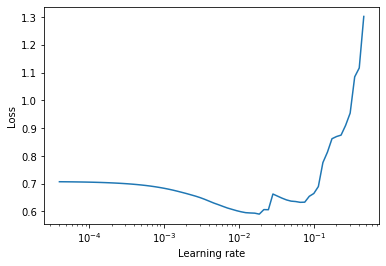

In [23]:
# Finds optimal learning rate
learner.lr_find(start_lr=1e-5,optimizer_type='lamb')

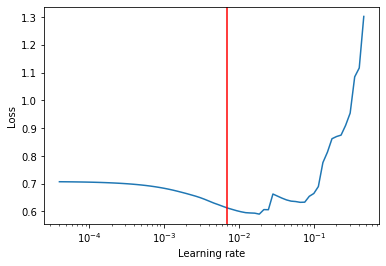

In [38]:
learner.plot(show_lr=7e-3)

In [33]:
# play with epochs 
# learner.fit(epochs=2,
#             lr=learner.get_last_lr(),
#             validate=True, 	# Evaluate the model after each epoch
#             schedule_type="warmup_cosine",
#             optimizer_type="lamb")

C:\Users\djons\Anaconda3\lib\site-packages\torch\optim\lr_scheduler.py:231: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  warnings.warn("To get the last learning rate computed by the scheduler, "


(2796, nan)

In [34]:
learner.save_model()

In [41]:
MODEL_PATH = OUTPUT_DIR+'model_out'

learner.predict("Am I showing cognitive presence?")

In [82]:
# plot metrics for loss over time to determine "optimal number of epochs"

thread_id
\x353839376639613464616436366330383065303030323136     True
\x356435366131623938343435326130376333303030623236    False
\x353865303730643666313730353630376264303032383633    False
\x353930303533333637656336663630376565303030373565    False
\x356430623964333064386561623130393430303032666561    False
                                                      ...  
\x356266376239653065663562333330396230303031666332    False
\x356266376131353933363130313330393761303031633665    False
\x356266373962346334666332333030613166303031323432    False
\x353936363930363532326138666230373535303032613264    False
\x356135626437323734346131353030386265303031333839    False
Name: thread_id, Length: 3809, dtype: bool